In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import easygui

In [11]:
path = easygui.fileopenbox()

In [13]:
df = pd.read_csv(path)
df

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB
None


In [19]:
df.describe(include = 'object')

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


In [21]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [23]:
print("\nTarget value counts:\n",df['status'].value_counts())


Target value counts:
 status
Placed        148
Not Placed     67
Name: count, dtype: int64


In [32]:
print("checking missing values:\n",df.isnull().sum())

checking missing values:
 sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [34]:
df.fillna(0,inplace = True)

In [36]:
print("checking missing values:\n",df.isnull().sum())

checking missing values:
 sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


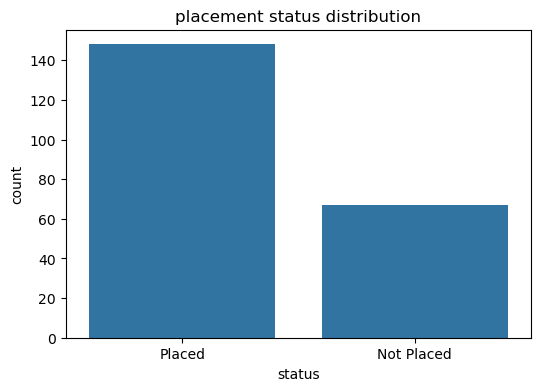

In [38]:
plt.figure(figsize = (6,4))
sns.countplot(data = df,x ='status')
plt.title('placement status distribution')
plt.show()

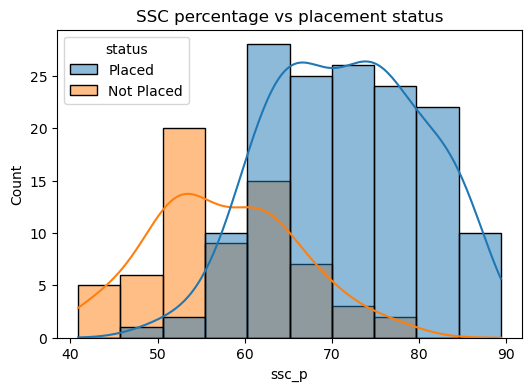

In [40]:
plt.figure(figsize = (6,4))
sns.histplot(data = df,x ='ssc_p',hue='status',kde=True)
plt.title('SSC percentage vs placement status')
plt.show()

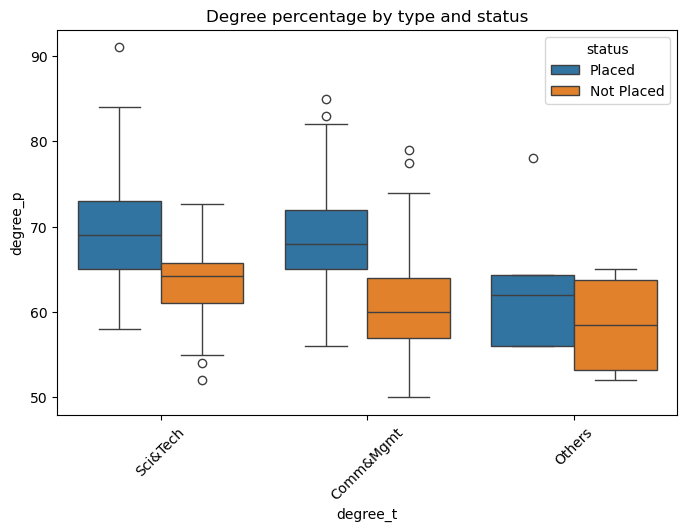

In [44]:
plt.figure(figsize = (8,5))
sns.boxplot(data = df,x ='degree_t',y='degree_p',hue = 'status')
plt.title('Degree percentage by type and status')
plt.xticks(rotation=45)
plt.show()

In [48]:
df = df.drop(columns = ['sl_no'])
df['status'] = df['status'].map({'Placed':1,'Not_Placed':0})

In [50]:
df['status'].fillna(0,inplace = True)

C:\Users\dell\AppData\Local\Temp\ipykernel_10680\1385596756.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['status'].fillna(0,inplace = True)


In [52]:
df['status']

0      1.0
1      1.0
2      1.0
3      0.0
4      1.0
      ... 
210    1.0
211    1.0
212    1.0
213    1.0
214    0.0
Name: status, Length: 215, dtype: float64

In [54]:
categorical_cols = df.select_dtypes(include = 'object').columns
categorical_cols

Index(['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex',
       'specialisation'],
      dtype='object')

In [58]:
df_encoded = pd.get_dummies(df,columns = categorical_cols,drop_first = True)
df_encoded

,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,67.00,91.00,58.00,55.0,58.80,1.0,270000.0,True,True,True,True,False,False,True,False,True
1,79.33,78.33,77.48,86.5,66.28,1.0,200000.0,True,False,True,False,True,False,True,True,False
2,65.00,68.00,64.00,75.0,57.80,1.0,250000.0,True,False,False,False,False,False,False,False,False
3,56.00,52.00,52.00,66.0,59.43,0.0,0.0,True,False,False,False,True,False,True,False,True
4,85.80,73.60,73.30,96.8,55.50,1.0,425000.0,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,91.0,74.49,1.0,400000.0,True,True,True,True,False,False,False,False,False
211,58.00,60.00,72.00,74.0,53.62,1.0,275000.0,True,True,True,False,True,False,True,False,False
212,67.00,67.00,73.00,59.0,69.72,1.0,295000.0,True,True,True,True,False,False,False,True,False
213,74.00,66.00,58.00,70.0,60.23,1.0,204000.0,False,True,True,True,False,False,False,False,True


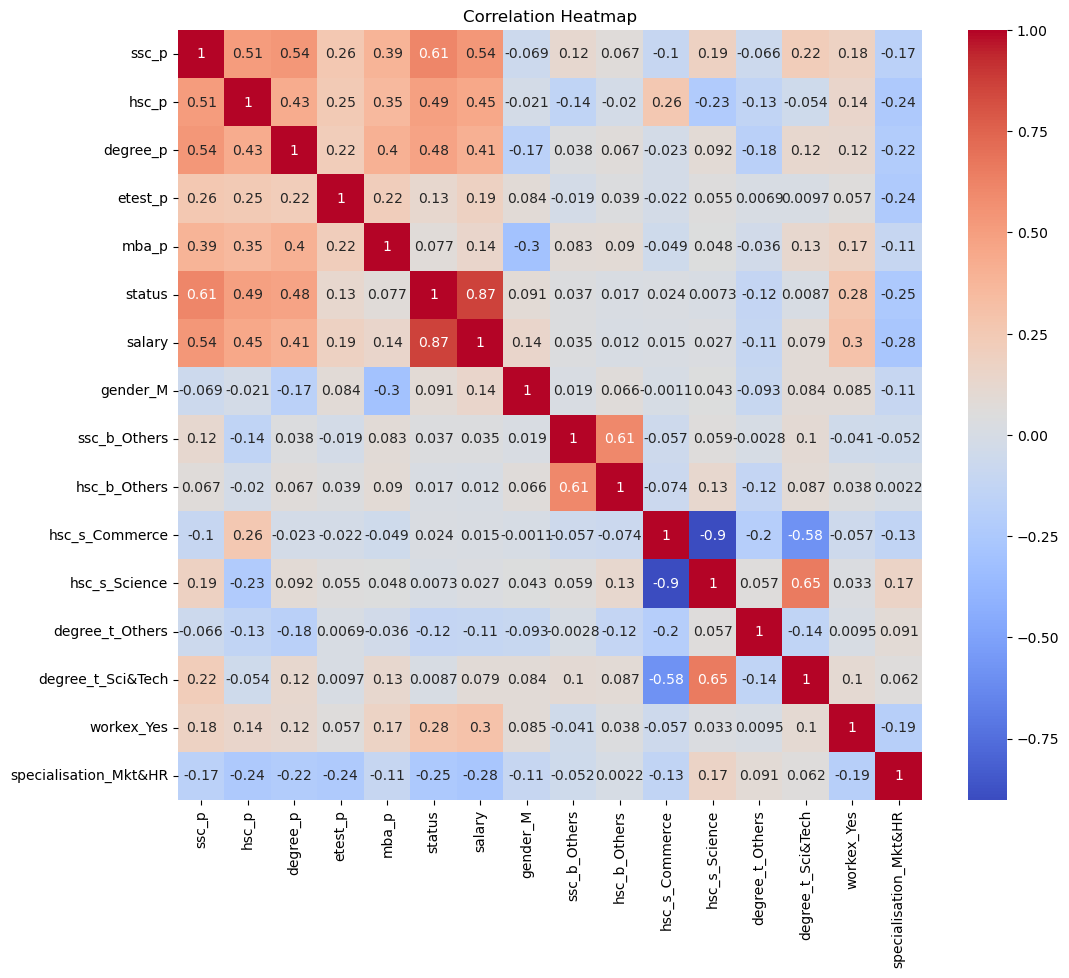

In [60]:
plt.figure(figsize = (12,10))
sns.heatmap(df_encoded.corr(),cmap = 'coolwarm',annot = True)
plt.title('Correlation Heatmap')
plt.show()

In [68]:
X = df_encoded.drop('status',axis = 1)
y = df_encoded['status']

In [72]:
X = X.fillna(0,inplace = True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)

In [74]:
model = LogisticRegression(max_iter = 1000)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [76]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 1.0


In [78]:
print("classification report:\n",classification_report(y_test,y_pred))

classification report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        13
         1.0       1.00      1.00      1.00        30

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



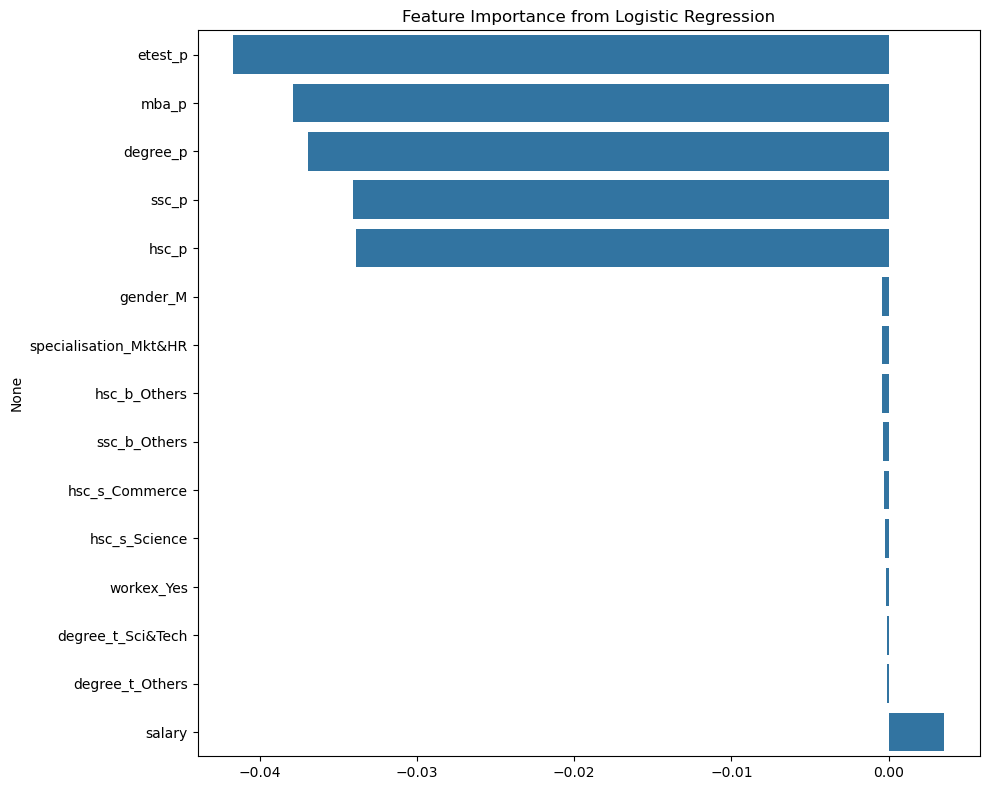

In [80]:
importance = pd.Series(model.coef_[0],index = x.columns).sort_values()
plt.figure(figsize=(10,8))
sns.barplot(x = importance.values,y = importance.index)
plt.title("Feature Importance from Logistic Regression")
plt.tight_layout()
plt.show()